# Experiment 1: Architecture Comparison

- Compare all three models (Assignment 1 baseline, LSTM/GRU, Transformer/BERT) using your task's metric
- Report training time, GPU memory, inference speed, and parameter count

In [ ]:
import os

if os.getcwd().split('/')[-1] == 'notebooks' or os.getcwd().split('\\')[-1] == 'notebooks':
    os.chdir('..')

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import os
from sklearn.pipeline import make_pipeline
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from src.preprocessing import get_preprocessed_data

SEED = 42
np.random.seed(SEED)

# Create directories
os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Load data
train_df, val_df, test_df, id2label, label2id = get_preprocessed_data()

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"\nEvasion label distribution:")
print(train_df['evasion_label'].value_counts())

Train: 2758, Val: 690, Test: 308

Evasion label distribution:
evasion_label
5    841
4    565
7    390
6    309
3    305
2    116
0     95
1     74
8     63
Name: count, dtype: int64


In [17]:
# Create contextual features
for df in [train_df, val_df, test_df]:
    df['sub_q_context'] = df['question'].fillna('') + " [SEP] " + df['interview_answer'].fillna('')
    

print("Features prepared!")
print(f"Text feature: sub_q_context")

Features prepared!
Text feature: sub_q_context


## Helpers

In [18]:
# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Results dictionary to build our final comparison table
experiment_results = []

def count_parameters(model):
    """Counts trainable parameters for PyTorch models."""
    if hasattr(model, 'parameters'):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    elif hasattr(model, 'coef_'): # For sklearn linear models
        return model.coef_.size + (model.intercept_.size if model.intercept_ is not None else 0)
    return 0

def gpu_memory_mb():
    """Peak GPU memory allocated since last reset (0 if CPU)."""
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / 1024 ** 2
    return 0.0

def reset_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

Using device: cuda


## Baseline

In [19]:
print("\n--- Baseline (CountVec + LogReg) ---")

baseline_pipeline = make_pipeline(
    CountVectorizer(ngram_range=(1, 2), stop_words="english"),
    LogisticRegression(max_iter=1000, random_state=SEED),
)

t0 = time.time()
baseline_pipeline.fit(train_df["sub_q_context"], train_df["evasion_label"])
train_time_baseline = time.time() - t0

t0 = time.time()
baseline_preds = baseline_pipeline.predict(val_df["sub_q_context"])
infer_time_baseline = time.time() - t0

experiment_results.append({
    "Architecture": "Baseline (CountVec + LogReg)",
    "Evasion F1 (Macro)": round(f1_score(val_df["evasion_label"], baseline_preds, average="macro"), 4),
    "Train Time (s)": round(train_time_baseline, 2),
    "Inference Speed (samples/s)": round(len(val_df) / infer_time_baseline, 1),
    "GPU Memory (MB)": 0.0,
    "Parameters": count_parameters(baseline_pipeline.named_steps["logisticregression"]),
})
print(f"  F1={experiment_results[-1]['Evasion F1 (Macro)']:.4f}  "
      f"train={train_time_baseline:.1f}s  "
      f"params={experiment_results[-1]['Parameters']:,}")


--- Baseline (CountVec + LogReg) ---
  F1=0.2823  train=138.9s  params=1,422,540


## GRU

In [20]:
# ---- tokenisation (simple word-index) ----------------------------------------
from collections import Counter

NUM_CLASSES = len(np.unique(train_df['evasion_label'])) 
MAX_VOCAB   = 15_000        # menos parámetros en embedding
MAX_SEQ_LEN = 128           # 128 está bien si lo necesitas
EMBED_DIM   = 128           # 128 también ok
HIDDEN_DIM  = 128           # ↓ bajar desde 256
NUM_LAYERS  = 1             # ↓ importante
BATCH_SIZE  = 32            # mejor para dataset pequeño
RNN_EPOCHS  = 25         # 50 es alto sin early stopping
LR_RNN      = 1e-3          # correcto
DROPOUT     = 0.3       # añadir sí o sí

In [21]:
def build_vocab(texts, max_vocab=MAX_VOCAB):
    counter = Counter(w for text in texts for w in text.lower().split())
    vocab = {"<pad>": 0, "<unk>": 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab


def encode_texts(texts, vocab, max_len=MAX_SEQ_LEN):
    unk = vocab["<unk>"]
    out = []
    for text in texts:
        ids = [vocab.get(w, unk) for w in text.lower().split()][:max_len]
        ids += [0] * (max_len - len(ids))
        out.append(ids)
    return torch.tensor(out, dtype=torch.long)


vocab = build_vocab(train_df["sub_q_context"])

class TextDatasetRNN(Dataset):
    def __init__(self, texts, labels):
        self.x = encode_texts(texts.tolist(), vocab)
        self.y = torch.tensor(labels.tolist(), dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.x[i], self.y[i]


train_rnn = DataLoader(TextDatasetRNN(train_df["sub_q_context"], train_df["evasion_label"]),
                       batch_size=BATCH_SIZE, shuffle=True)
val_rnn   = DataLoader(TextDatasetRNN(val_df["sub_q_context"],   val_df["evasion_label"]),
                       batch_size=BATCH_SIZE, shuffle=False)


class UniGRUClassifier(nn.Module):
    """Unidirectional GRU with attention pooling."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Set bidirectional=False
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, bidirectional=False, dropout=dropout)
        # Dimension is now just hidden_dim
        self.attn = nn.Linear(hidden_dim, 1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        emb = self.embedding(x)                       
        out, _ = self.gru(emb)                        # out: (B, L, H)
        weights = torch.softmax(self.attn(out), dim=1)# weights: (B, L, 1)
        ctx = (out * weights).sum(dim=1)              # ctx: (B, H)
        return self.classifier(ctx)

In [22]:
rnn_model = UniGRUClassifier(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT 
).to(device)

optimizer_rnn = torch.optim.Adam(rnn_model.parameters(), lr=LR_RNN)
criterion = nn.CrossEntropyLoss()

reset_gpu_memory()
t0 = time.time()

for epoch in range(RNN_EPOCHS):
    rnn_model.train()
    total_loss = 0
    for xb, yb in train_rnn:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_rnn.zero_grad()
        loss = criterion(rnn_model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(rnn_model.parameters(), 1.0)
        optimizer_rnn.step()
        total_loss += loss.item()
    print(f"  [GRU] epoch {epoch+1}/{RNN_EPOCHS}  loss={total_loss/len(train_rnn):.4f}")

train_time_rnn = time.time() - t0
gpu_mem_rnn    = gpu_memory_mb()

# Inference
rnn_model.eval()
all_preds, all_labels = [], []
t0 = time.time()
with torch.no_grad():
    for xb, yb in val_rnn:
        preds = rnn_model(xb.to(device)).argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(yb.tolist())
infer_time_rnn = time.time() - t0

experiment_results.append({
    "Architecture": "UniGRU (attention)",
    "Evasion F1 (Macro)": round(f1_score(all_labels, all_preds, average="macro"), 4),
    "Train Time (s)": round(train_time_rnn, 2),
    "Inference Speed (samples/s)": round(len(val_df) / infer_time_rnn, 1),
    "GPU Memory (MB)": round(gpu_mem_rnn, 1),
    "Parameters": count_parameters(rnn_model),
})
print(f"  F1 Val={experiment_results[-1]['Evasion F1 (Macro)']:.4f}  "
      f"train={train_time_rnn:.1f}s  "
      f"params={experiment_results[-1]['Parameters']:,}")

/home/alumno/py313ml/.venv/lib/python3.13/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


  [GRU] epoch 1/25  loss=1.9220
  [GRU] epoch 2/25  loss=1.8256
  [GRU] epoch 3/25  loss=1.7813
  [GRU] epoch 4/25  loss=1.6866
  [GRU] epoch 5/25  loss=1.5364
  [GRU] epoch 6/25  loss=1.3416
  [GRU] epoch 7/25  loss=1.1970
  [GRU] epoch 8/25  loss=1.0278
  [GRU] epoch 9/25  loss=0.8740
  [GRU] epoch 10/25  loss=0.7429
  [GRU] epoch 11/25  loss=0.6408
  [GRU] epoch 12/25  loss=0.5551
  [GRU] epoch 13/25  loss=0.4565
  [GRU] epoch 14/25  loss=0.3802
  [GRU] epoch 15/25  loss=0.3191
  [GRU] epoch 16/25  loss=0.2584
  [GRU] epoch 17/25  loss=0.2246
  [GRU] epoch 18/25  loss=0.1883
  [GRU] epoch 19/25  loss=0.1582
  [GRU] epoch 20/25  loss=0.1403
  [GRU] epoch 21/25  loss=0.1213
  [GRU] epoch 22/25  loss=0.1179
  [GRU] epoch 23/25  loss=0.0838
  [GRU] epoch 24/25  loss=0.0782
  [GRU] epoch 25/25  loss=0.0745
  F1 Val=0.2574  train=12.0s  params=2,020,362


## LSTM

In [23]:
class UniLSTMClassifier(nn.Module):
    """Unidirectional LSTM with attention pooling."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout=0.3):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,   # unidirectional
            dropout=dropout
        )

        self.attn = nn.Linear(hidden_dim, 1)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        emb = self.embedding(x)                 # (B, L, E)
        out, _ = self.lstm(emb)                 # (B, L, H)
        weights = torch.softmax(self.attn(out), dim=1)
        ctx = (out * weights).sum(dim=1)        # (B, H)
        return self.classifier(ctx)

In [24]:
lstm_model = UniLSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT 
).to(device)

optimizer_lstm = torch.optim.Adam(lstm_model.parameters(), lr=LR_RNN)
criterion = nn.CrossEntropyLoss()

/home/alumno/py313ml/.venv/lib/python3.13/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


In [25]:
reset_gpu_memory()
t0 = time.time()

for epoch in range(RNN_EPOCHS):
    lstm_model.train()
    total_loss = 0

    for xb, yb in train_rnn:
        xb, yb = xb.to(device), yb.to(device)

        optimizer_lstm.zero_grad()
        loss = criterion(lstm_model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        optimizer_lstm.step()

        total_loss += loss.item()

    print(f"  [LSTM] epoch {epoch+1}/{RNN_EPOCHS}  loss={total_loss/len(train_rnn):.4f}")

train_time_lstm = time.time() - t0
gpu_mem_lstm = gpu_memory_mb()

  [LSTM] epoch 1/25  loss=1.9321
  [LSTM] epoch 2/25  loss=1.8379
  [LSTM] epoch 3/25  loss=1.8023
  [LSTM] epoch 4/25  loss=1.7358
  [LSTM] epoch 5/25  loss=1.6365
  [LSTM] epoch 6/25  loss=1.5223
  [LSTM] epoch 7/25  loss=1.4032
  [LSTM] epoch 8/25  loss=1.2762
  [LSTM] epoch 9/25  loss=1.1493
  [LSTM] epoch 10/25  loss=1.0270
  [LSTM] epoch 11/25  loss=0.9131
  [LSTM] epoch 12/25  loss=0.7788
  [LSTM] epoch 13/25  loss=0.6792
  [LSTM] epoch 14/25  loss=0.5737
  [LSTM] epoch 15/25  loss=0.4876
  [LSTM] epoch 16/25  loss=0.4334
  [LSTM] epoch 17/25  loss=0.3752
  [LSTM] epoch 18/25  loss=0.3245
  [LSTM] epoch 19/25  loss=0.2983
  [LSTM] epoch 20/25  loss=0.2703
  [LSTM] epoch 21/25  loss=0.2293
  [LSTM] epoch 22/25  loss=0.1994
  [LSTM] epoch 23/25  loss=0.1831
  [LSTM] epoch 24/25  loss=0.1636
  [LSTM] epoch 25/25  loss=0.1419


In [26]:
lstm_model.eval()
all_preds, all_labels = [], []

t0 = time.time()
with torch.no_grad():
    for xb, yb in val_rnn:
        preds = lstm_model(xb.to(device)).argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(yb.tolist())

infer_time_lstm = time.time() - t0

experiment_results.append({
    "Architecture": "UniLSTM (attention)",
    "Evasion F1 (Macro)": round(f1_score(all_labels, all_preds, average="macro"), 4),
    "Train Time (s)": round(train_time_lstm, 2),
    "Inference Speed (samples/s)": round(len(val_df) / infer_time_lstm, 1),
    "GPU Memory (MB)": round(gpu_mem_lstm, 1),
    "Parameters": count_parameters(lstm_model),
})

print(f"  F1 Val={experiment_results[-1]['Evasion F1 (Macro)']:.4f}  "
      f"train={train_time_lstm:.1f}s  "
      f"params={experiment_results[-1]['Parameters']:,}")

  F1 Val=0.2318  train=9.6s  params=2,053,386


## BERT

In [27]:
MODEL_NAME    = "bert-base-uncased"
BERT_EPOCHS   = 20
BERT_BATCH    = 16
LR_BERT       = 2e-5
MAX_LEN_BERT  = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class EvasionDataset(Dataset):
    def __init__(self, texts, labels, max_length=MAX_LEN_BERT):
        self.encodings = tokenizer(
            texts.tolist(), truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt",
        )
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)


In [28]:
train_bert = DataLoader(EvasionDataset(train_df["sub_q_context"], train_df["evasion_label"]),
                        batch_size=BERT_BATCH, shuffle=True)
val_bert   = DataLoader(EvasionDataset(val_df["sub_q_context"],   val_df["evasion_label"]),
                        batch_size=32, shuffle=False)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES
).to(device)

optimizer_bert = torch.optim.AdamW(bert_model.parameters(), lr=LR_BERT)
from transformers import get_linear_schedule_with_warmup
total_steps = len(train_bert) * BERT_EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer_bert, num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

reset_gpu_memory()
t0 = time.time()

for epoch in range(BERT_EPOCHS):
    bert_model.train()
    total_loss = 0
    for batch in train_bert:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = bert_model(**batch)
        loss = outputs.loss
        loss.backward()
        nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer_bert.step()
        scheduler.step()
        optimizer_bert.zero_grad()
        total_loss += loss.item()
    print(f"  [BERT] epoch {epoch+1}/{BERT_EPOCHS}  loss={total_loss/len(train_bert):.4f}")

train_time_bert = time.time() - t0
gpu_mem_bert    = gpu_memory_mb()

# Inference
bert_model.eval()
all_preds, all_labels = [], []
t0 = time.time()
with torch.no_grad():
    for batch in val_bert:
        batch = {k: v.to(device) for k, v in batch.items()}
        preds = bert_model(**batch).logits.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(batch["labels"].cpu().tolist())
infer_time_bert = time.time() - t0

experiment_results.append({
    "Architecture": "BERT (bert-base-uncased)",
    "Evasion F1 (Macro)": round(f1_score(all_labels, all_preds, average="macro"), 4),
    "Train Time (s)": round(train_time_bert, 2),
    "Inference Speed (samples/s)": round(len(val_df) / infer_time_bert, 1),
    "GPU Memory (MB)": round(gpu_mem_bert, 1),
    "Parameters": count_parameters(bert_model),
})
print(f"  F1 Val={experiment_results[-1]['Evasion F1 (Macro)']:.4f}  "
      f"train={train_time_bert:.1f}s  "
      f"params={experiment_results[-1]['Parameters']:,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [BERT] epoch 1/20  loss=1.9908
  [BERT] epoch 2/20  loss=1.8161
  [BERT] epoch 3/20  loss=1.6748
  [BERT] epoch 4/20  loss=1.4717
  [BERT] epoch 5/20  loss=1.2008
  [BERT] epoch 6/20  loss=0.9237
  [BERT] epoch 7/20  loss=0.6887
  [BERT] epoch 8/20  loss=0.5053
  [BERT] epoch 9/20  loss=0.3632
  [BERT] epoch 10/20  loss=0.2548
  [BERT] epoch 11/20  loss=0.1870
  [BERT] epoch 12/20  loss=0.1367
  [BERT] epoch 13/20  loss=0.1075
  [BERT] epoch 14/20  loss=0.0815
  [BERT] epoch 15/20  loss=0.0761
  [BERT] epoch 16/20  loss=0.0632
  [BERT] epoch 17/20  loss=0.0571
  [BERT] epoch 18/20  loss=0.0421
  [BERT] epoch 19/20  loss=0.0398
  [BERT] epoch 20/20  loss=0.0357
  F1 Val=0.3387  train=255.6s  params=109,489,161


## Results table

In [29]:
results_df = pd.DataFrame(experiment_results)
results_df["Parameters"] = results_df["Parameters"].apply(lambda x: f"{x:,}")
print("\n\n===== FINAL COMPARISON =====")
print(results_df.to_string(index=False))
results_df.to_csv("results/model_comparison.csv", index=False)



===== FINAL COMPARISON =====
                Architecture  Evasion F1 (Macro)  Train Time (s)  Inference Speed (samples/s)  GPU Memory (MB)  Parameters
Baseline (CountVec + LogReg)              0.2823          138.91                       3716.1              0.0   1,422,540
          UniGRU (attention)              0.2574           12.02                      34620.5           1405.7   2,020,362
         UniLSTM (attention)              0.2318            9.61                      20377.6           1409.8   2,053,386
    BERT (bert-base-uncased)              0.3387          255.58                       1130.0           2610.6 109,489,161


## Visualizations

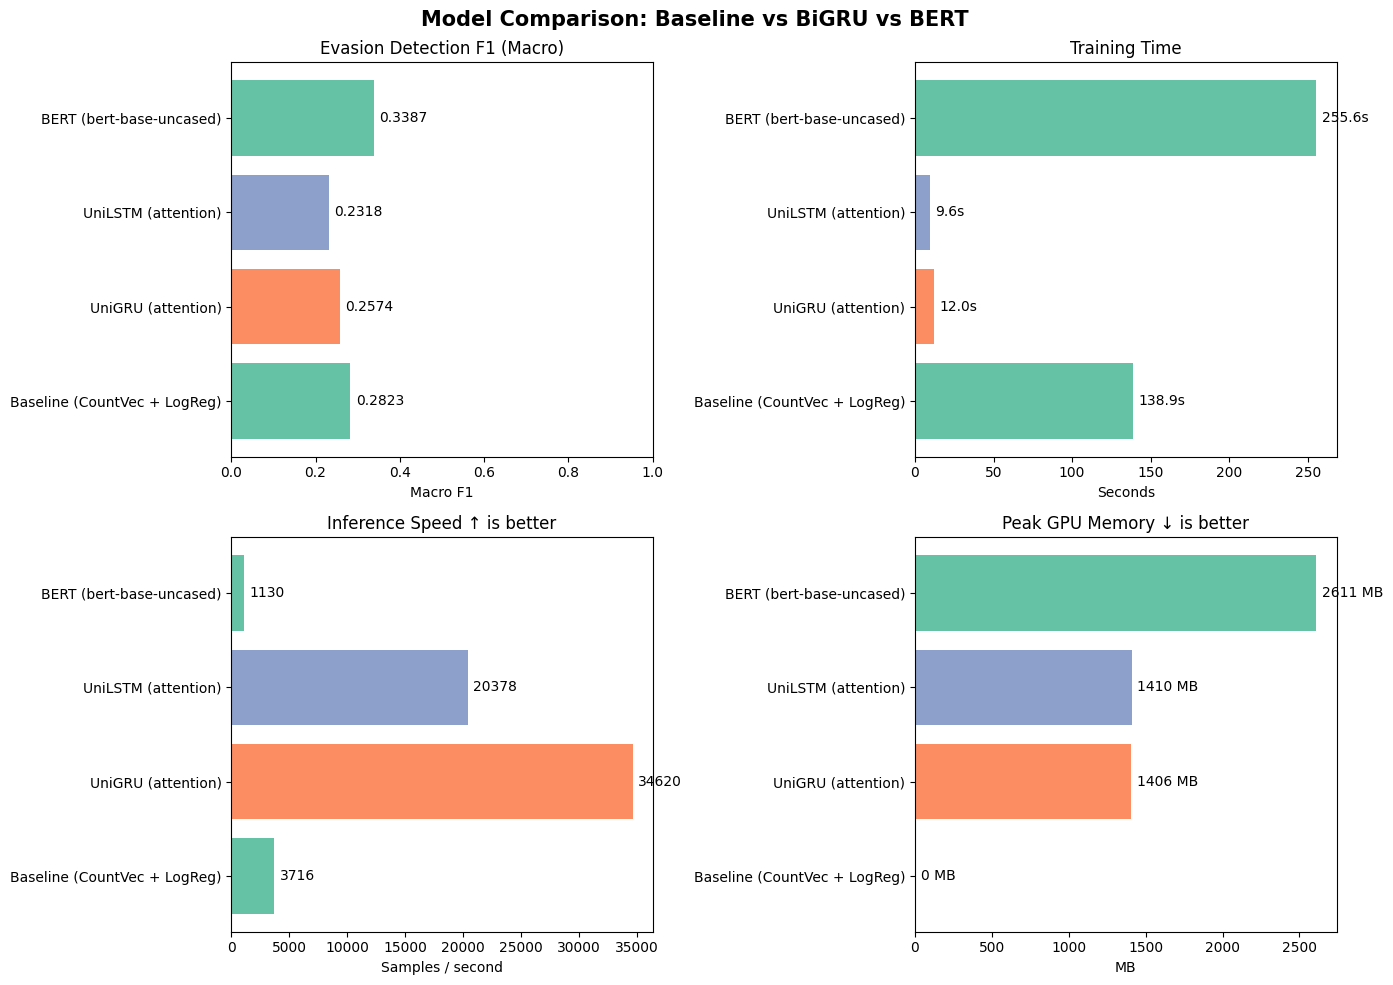


Figure saved → figures/model_comparison.png
Table  saved → results/model_comparison.csv


In [30]:
metrics_num = pd.DataFrame(experiment_results)  # numeric version

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Model Comparison: Baseline vs BiGRU vs BERT", fontsize=15, fontweight="bold")

palette = sns.color_palette("Set2", 3)
archs   = metrics_num["Architecture"]

# F1
ax = axes[0, 0]
bars = ax.barh(archs, metrics_num["Evasion F1 (Macro)"], color=palette)
ax.bar_label(bars, fmt="%.4f", padding=4)
ax.set_xlabel("Macro F1")
ax.set_title("Evasion Detection F1 (Macro)")
ax.set_xlim(0, 1.0)

# Training time
ax = axes[0, 1]
bars = ax.barh(archs, metrics_num["Train Time (s)"], color=palette)
ax.bar_label(bars, fmt="%.1fs", padding=4)
ax.set_xlabel("Seconds")
ax.set_title("Training Time")

# Inference speed
ax = axes[1, 0]
bars = ax.barh(archs, metrics_num["Inference Speed (samples/s)"], color=palette)
ax.bar_label(bars, fmt="%.0f", padding=4)
ax.set_xlabel("Samples / second")
ax.set_title("Inference Speed ↑ is better")

# GPU memory
ax = axes[1, 1]
bars = ax.barh(archs, metrics_num["GPU Memory (MB)"], color=palette)
ax.bar_label(bars, fmt="%.0f MB", padding=4)
ax.set_xlabel("MB")
ax.set_title("Peak GPU Memory ↓ is better")

plt.tight_layout()
plt.savefig("figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nFigure saved → figures/model_comparison.png")
print("Table  saved → results/model_comparison.csv")